In [1]:
pip install numpy==1.26.4


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-surprise


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [147]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os

from surprise import SVD, KNNBasic
from surprise.model_selection import cross_validate, train_test_split
from surprise.model_selection import RandomizedSearchCV, GridSearchCV
from surprise.accuracy import rmse, mae

In [4]:
os.getcwd()

'/Users/thanyabegum/Desktop/Intelligence Internship'

In [34]:
# Load datasets
movie = pd.read_csv('/Users/thanyabegum/Desktop/Intelligence Internship/tmdb_5000_movies.csv')
credits = pd.read_csv("/Users/thanyabegum/Desktop/Intelligence Internship/tmdb_5000_credits.csv")

# Merge both datasets on title
movies = movie.merge(credits, on='title')

# Keep important columns
movies = movies[['id', 'title', 'overview', 'keywords', 'genres', 'cast', 'crew']]

# Drop rows with null values
movies.dropna(inplace=True)

/var/folders/db/f169cvcd0qj9s7f8vp0k_r8w0000gn/T/ipykernel_7625/1203649096.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,25

In [6]:
movies.head()

,id,title,overview,keywords,genres,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [126]:
movies.nunique()

id          1489
title       1487
overview    1489
keywords    1456
genres       619
cast        1487
crew        1487
dtype: int64

In [124]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1489 entries, 0 to 1491
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        1489 non-null   int64 
 1   title     1489 non-null   object
 2   overview  1489 non-null   object
 3   keywords  1489 non-null   object
 4   genres    1489 non-null   object
 5   cast      1489 non-null   object
 6   crew      1489 non-null   object
dtypes: int64(1), object(6)
memory usage: 93.1+ KB


In [7]:
# Process 'overview' column
movies['overview'] = movies['overview'].apply(lambda x: x.split())

# Process 'keywords' column
def convert_keywords(obj):
    l = []
    for i in ast.literal_eval(obj):
        l.append(i['name'])
    return l

movies['keywords'] = movies['keywords'].apply(convert_keywords)

In [8]:
# Process 'genres' column
def convert_genres(obj):
    l = []
    for i in ast.literal_eval(obj):
        l.append(i['name'])
    return l

movies['genres'] = movies['genres'].apply(convert_genres)

In [9]:
# Process 'cast' column (top 3 only)
def extract_cast(obj):
    l = []
    count = 0
    for i in ast.literal_eval(obj):
        if count != 3:
            l.append(i['name'])
            count += 1
        else:
            break
    return l

movies['cast'] = movies['cast'].apply(extract_cast)

In [10]:
# Process 'crew' column (get director only)
def extract_director(obj):
    l = []

    try:
        data = ast.literal_eval(obj)

        for i in data:
            if i.get('job') == 'Director':
                l.append(i.get('name'))
                break

    except Exception as e:
        return []

    return l

movies['crew'] = movies['crew'].apply(extract_director)

In [11]:
movies.head()

,id,title,overview,keywords,genres,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[culture clash, future, space war, space colon...","[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[ocean, drug abuse, exotic island, east india ...","[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[spy, based on novel, secret agent, sequel, mi...","[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[dc comics, crime fighter, terrorist, secret i...","[Action, Crime, Drama, Thriller]","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[based on novel, mars, medallion, space travel...","[Action, Adventure, Science Fiction]","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [12]:
# Create 'tags' column by combining overview + keywords + genres + cast + crew
movies['tags'] = movies['overview'] + movies['cast'] + movies['crew'] + movies['keywords']

# Final dataset with relevant columns
movies = movies[['id', 'title', 'tags']]

In [13]:
movies.head()

,id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."


In [14]:
# Remove spaces from tags
movies['tags'] = movies['tags'].apply(lambda x: [i.replace(" ", "") for i in x])

# Stemming
ps = PorterStemmer()

def stemming(text):
    l = []
    for i in text:
        l.append(ps.stem(i))
    return " ".join(l)

movies['tags'] = movies['tags'].apply(stemming)

In [15]:
movies

,id,title,tags
0,19995,Avatar,"in the 22nd century, a parapleg marin is dispa..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believ to be dead, ha c..."
2,206647,Spectre,a cryptic messag from bond’ past send him on a...
3,49026,The Dark Knight Rises,follow the death of district attorney harvey d...
4,49529,John Carter,"john carter is a war-weary, former militari ca..."
...,...,...,...
1487,9763,Goal!: The Dream Begins,"like million of kid around the world, santiago..."
1488,72387,Safe,after a former elit agent rescu a 12-year-old ...
1489,12596,Pushing Tin,"two air traffic control (john cusack, billi bo..."
1490,1255,The Host,gang-du is a dim-wit man work at hi father' ti...


In [16]:
# Vectorization
vectorizer = CountVectorizer(max_features=500, stop_words='english')
vectors = vectorizer.fit_transform(movies['tags']).toarray()

# Cosine similarity
similarity = cosine_similarity(vectors)

In [27]:
# Recommendation function
def Recommendation_system(movie_title):
    movie_index = movies[movies['title'] == movie_title].index[0]
    distances = sorted(list(enumerate(similarity[movie_index])), reverse=True, key=lambda x: x[1])
    
    for i in distances[1:20]:
        print(movies.iloc[i[0]].title)

# Example usage
Recommendation_system("The Dark Knight Rises")

Teenage Mutant Ninja Turtles
Batman
Zero Dark Thirty
Batman & Robin
Eraser
Iron Man 3
Mission: Impossible
Bulletproof Monk
Batman Forever
The Out-of-Towners
The Siege
City By The Sea
Mission: Impossible III
Bless the Child
Mercury Rising
X-Men
Safe
The Day After Tomorrow
Max Payne


In [34]:
# Save the model and data
pickle.dump(movies, open('model.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))

# BONUS TASKS

In [43]:
movie_new = pd.read_csv("/Users/thanyabegum/Desktop/Intelligence Internship/movies.csv", )
ratings = pd.read_csv("/Users/thanyabegum/Desktop/Intelligence Internship/ratings.csv")
movie_new.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [44]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [55]:
print(movie_new.isna().sum())
print(f"\n{ratings.isna().sum()}")

movieId    0
title      0
genres     0
dtype: int64

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [50]:
print(movie_new.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


In [74]:
print(movie_new["title"].nunique())
movie_new["title"].value_counts().head(10)

9737


title
Emma (1996)                                                    2
War of the Worlds (2005)                                       2
Confessions of a Dangerous Mind (2002)                         2
Eros (2004)                                                    2
Saturn 3 (1980)                                                2
Paranoid Park (2007)                                           1
I'm a Cyborg, But That's OK (Saibogujiman kwenchana) (2006)    1
Bug (2007)                                                     1
Mr. Brooks (2007)                                              1
Librarian: Return to King Solomon's Mines, The (2006)          1
Name: count, dtype: int64

In [51]:
print(movie_new.info())
print(ratings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


In [53]:
print(movie_new.describe())
print(f"\n{ratings.describe()}")

             movieId
count    9742.000000
mean    42200.353623
std     52160.494854
min         1.000000
25%      3248.250000
50%      7300.000000
75%     76232.000000
max    193609.000000

              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09


# Exploratory Data Analysis

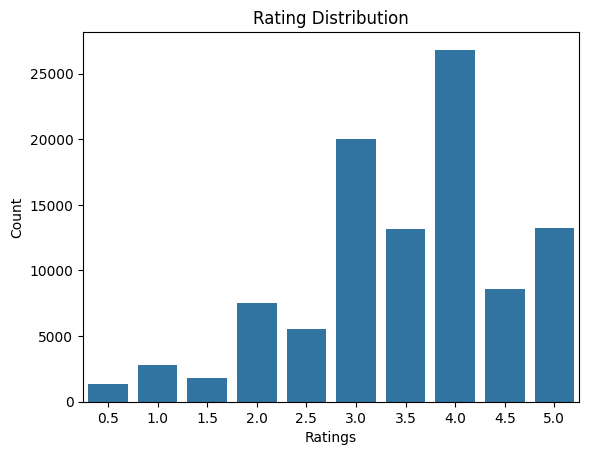

In [58]:
sns.countplot(x=ratings["rating"])
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

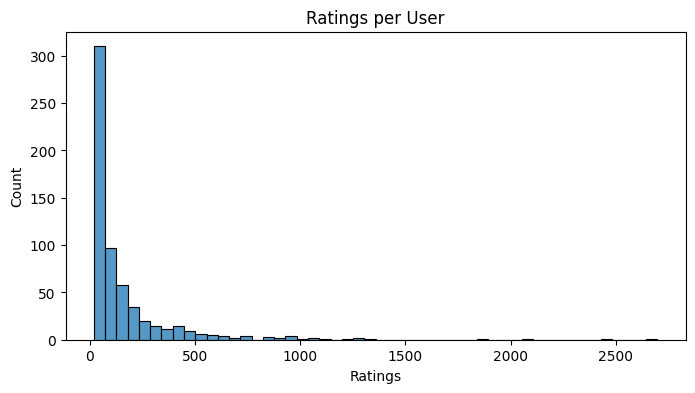

In [59]:
ratings_per_user = ratings.groupby("userId")["rating"].count()

plt.figure(figsize=(8,4))
sns.histplot(ratings_per_user, bins=50)
plt.title("Ratings per User")
plt.xlabel("Ratings")
plt.show()

In [60]:
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

# SVD

In [101]:
algo = SVD()

algo.fit(trainset)

svd_predictions = algo.test(testset)

rmse(svd_predictions)
mae(svd_predictions)

RMSE: 0.8783
MAE:  0.6747


0.6747291712108491

In [102]:
# Hypertuning SVD
param_grid = {
    "n_factors": [10, 20, 50, 75, 100, 150],
    "n_epochs": [10, 20, 30, 40, 50],
    "lr_all": [0.002, 0.005, 0.01],
    "reg_all": [0.02, 0.05, 0.1]
}

grid = GridSearchCV(
    SVD,
    param_grid,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1
)

grid.fit(data)

In [103]:
print(rs.best_score["rmse"])
print(rs.best_params["rmse"])

0.8586688668598276
{'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.1}


In [ ]:
algo = SVD(
    n_factors=150,
    n_epochs=50,
    lr_all=0.01,
    reg_all=0.1
)

algo.fit(trainset)

svd_predictions = algo.test(testset)

rmse(svd_predictions)
mae(svd_predictions)

RMSE: 0.8563
MAE:  0.6554


# KNN

In [100]:
model = KNNBasic()
model.fit(trainset)

knn_predictions = model.test(testset)
rmse(knn_predictions)
mae(knn_predictions)

Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 0.9578
MAE:  0.7333


0.7332649893867501

In [ ]:
# Hypertuning knn
knn_param = {
    "k": [20, 40, 60, 80, 100],
    "min_k": [1, 3, 5, 10],
    "sim_options": {
        "name": ["msd", "cosine", "pearson"],
        "user_based": [True, False]
    }
}

gs = GridSearchCV(
    KNNBasic,
    knn_param,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1)

gs.fit(data)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity mat

In [112]:
print(gs.best_score["rmse"])
print(gs.best_params["rmse"])

0.9125620819747661
{'k': 80, 'min_k': 5, 'sim_options': {'name': 'msd', 'user_based': False}}


In [115]:
model = KNNBasic(
    k=80,
    min_k=5,
    sim_options={
        "name": "msd",
        "user_based": False
    }
)
model.fit(trainset)

knn_predictions = model.test(testset)
rmse(knn_predictions)
mae(knn_predictions)

Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 0.9091
MAE:  0.6977


0.6977038318338361

# Hybrid Recommender

In [142]:
movie_new['genres'] = movie_new['genres'].fillna('')
movie_new['content'] = movie_new['genres'] 

In [159]:
movie_new

,movieId,title,genres,content
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy,Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy,Comedy
...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama,Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,Action|Animation


In [148]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movie_new['content'])

In [149]:
content_similarity = cosine_similarity(tfidf_matrix)

In [151]:
indices = pd.Series(movie_new.index, index=movie_new['title'])

def content_recommendations(title, top_n=10):
    idx = indices[title]

    sim_scores = list(enumerate(content_similarity[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    return movie_new[['title']].iloc[movie_indices]

In [162]:
def collaborative_score(user_id, movie_id):
    pred = algo.predict(user_id, movie_id)
    return pred.est

In [ ]:
# Combining SVD predictive ratings with content similarity.
def hybrid_recommend(user_id, favorite_movie, top_n=10):

    idx = indices[favorite_movie]

    sim_scores = list(enumerate(content_similarity[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:50]

    movie_scores = []

    for movie_idx, content_score in sim_scores:

        movie_id = movie_new.iloc[movie_idx]['movieId']

        collab_score = collaborative_score(user_id, movie_id)

        hybrid_score = (0.4 * content_score) + (0.6 * collab_score)

        movie_scores.append((
            movie_new.iloc[movie_idx]['title'],
            hybrid_score
        ))

    movie_scores = sorted(movie_scores,
                          key=lambda x: x[1],
                          reverse=True)

    return movie_scores[:top_n]

In [164]:
hybrid_recommend(
    user_id=1,
    favorite_movie="Bungo Stray Dogs: Dead Apple (2018)",
    top_n=10
)

[('Batman: The Dark Knight Returns, Part 2 (2013)', 3.1233800872454838),
 ('Big Hero 6 (2014)', 3.118080480493145),
 ('Batman: Under the Red Hood (2010)', 3.043371680646474),
 ('Town Called Panic, A (Panique au village) (2009)', 3.0421467287113626),
 ('Dragon Ball Z: The History of Trunks (Doragon bôru Z: Zetsubô e no hankô!! Nokosareta chô senshi - Gohan to Torankusu) (1993)',
  3.00151827308844),
 ('The Lego Batman Movie (2017)', 2.9853795320028107),
 ('Ooops! Noah is Gone... (2015)', 2.979891509493853),
 ('How to Train Your Dragon 2 (2014)', 2.958789623687185),
 ('Dragon Ball Z: Broly - The Legendary Super Saiyan (Doragon bôru Z 8: Moetsukiro!! Nessen retsusen-chô gekisen) (1993)',
  2.9547018879546756),
 ('Superman/Doomsday (2007) ', 2.9398899224092503)]